In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.pyplot as plt

2026-04-29 18:18:29.446562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777486709.829372      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777486709.934575      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777486710.801760      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777486710.801824      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777486710.801827      57 computation_placer.cc:177] computation placer alr

In [2]:
TRAIN_LR = "/kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/train/low_res"
TRAIN_HR = "/kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/train/high_res"

VAL_LR = "/kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/val/low_res"
VAL_HR = "/kaggle/input/datasets/adityachandrasekhar/image-super-resolution/dataset/val/high_res"

In [3]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

def load_images(lr_path, hr_path):
    lr_images, hr_images = [], []
    
    lr_files = sorted(os.listdir(lr_path))
    hr_files = sorted(os.listdir(hr_path))
    
    for lr, hr in zip(lr_files, hr_files):
        lr_img = cv2.imread(os.path.join(lr_path, lr))
        hr_img = cv2.imread(os.path.join(hr_path, hr))
        
        lr_img = cv2.resize(lr_img, (IMG_SIZE, IMG_SIZE))
        hr_img = cv2.resize(hr_img, (IMG_SIZE*2, IMG_SIZE*2))
        
        lr_images.append(lr_img / 255.0)
        hr_images.append(hr_img / 255.0)
    
    return np.array(lr_images), np.array(hr_images)

# Load data
x_train, y_train = load_images(TRAIN_LR, TRAIN_HR)
x_val, y_val = load_images(VAL_LR, VAL_HR)

print(x_train.shape, y_train.shape)

(685, 128, 128, 3) (685, 256, 256, 3)


In [4]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def build_generator():
    inputs = Input(shape=(128,128,3))
    
    x = Conv2D(64, 9, padding='same', activation='relu')(inputs)
    
    for _ in range(4):
        x = Conv2D(64, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
    
    x = UpSampling2D()(x)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    
    outputs = Conv2D(3, 9, padding='same', activation='sigmoid')(x)
    
    return Model(inputs, outputs)

In [5]:
def build_discriminator():
    inputs = Input(shape=(256,256,3))
    
    x = Conv2D(64, 3, strides=2, padding='same')(inputs)
    x = LeakyReLU(0.2)(x)
    
    for f in [64,128,256]:
        x = Conv2D(f, 3, strides=2, padding='same')(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(0.2)(x)
    
    x = Flatten()(x)
    x = Dense(512)(x)
    x = LeakyReLU(0.2)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

In [ ]:
def residual_block(x):
    res = Conv2D(64, 3, padding='same')(x)
    res = BatchNormalization()(res)
    res = PReLU(shared_axes=[1,2])(res)
    
    res = Conv2D(64, 3, padding='same')(res)
    res = BatchNormalization()(res)
    
    return Add()([x, res])

In [6]:
def build_srgan_generator():
    inputs = Input(shape=(128,128,3))
    
    x = Conv2D(64, 9, padding='same')(inputs)
    x = PReLU(shared_axes=[1,2])(x)
    
    skip = x
    
    for _ in range(8):
        x = residual_block(x)
    
    x = Conv2D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Add()([x, skip])
    
    # Upsampling
    for _ in range(2):
        x = UpSampling2D()(x)
        x = Conv2D(256, 3, padding='same')(x)
        x = PReLU(shared_axes=[1,2])(x)
    
    outputs = Conv2D(3, 9, padding='same', activation='tanh')(x)
    
    return Model(inputs, outputs)

In [7]:
def dense_block(x):
    for _ in range(3):
        temp = Conv2D(64, 3, padding='same')(x)
        temp = LeakyReLU(0.2)(temp)
        x = Concatenate()([x, temp])
    return x

In [8]:
def build_esrgan():
    inputs = Input(shape=(128,128,3))
    
    x = Conv2D(64, 3, padding='same')(inputs)
    
    for _ in range(5):
        x = dense_block(x)
    
    # Upsampling
    x = UpSampling2D()(x)
    x = Conv2D(64, 3, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    
    x = UpSampling2D()(x)
    x = Conv2D(64, 3, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    
    outputs = Conv2D(3, 3, padding='same', activation='tanh')(x)
    
    return Model(inputs, outputs)

In [9]:
from tensorflow.keras.optimizers import Adam

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002), metrics=['accuracy'])

discriminator.trainable = False

gan_input = Input(shape=(128,128,3))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))

2026-04-29 18:19:30.093570: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
epochs = 5
batch_size = 8

for epoch in range(epochs):
    
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    
    lr_imgs = x_train[idx]
    hr_imgs = y_train[idx]
    
    fake_hr = generator.predict(lr_imgs)
    
    d_loss_real = discriminator.train_on_batch(hr_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_hr, np.zeros((batch_size,1)))
    
    g_loss = gan.train_on_batch(lr_imgs, np.ones((batch_size,1)))
    
    print(f"Epoch {epoch} | D Loss: {d_loss_real[0]} | G Loss: {g_loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.6654558181762695 | G Loss: 0.6624561548233032
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Epoch 1 | D Loss: 0.6876875758171082 | G Loss: 0.656616747379303
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Epoch 2 | D Loss: 0.6918078660964966 | G Loss: 0.6514200568199158
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Epoch 3 | D Loss: 0.6927140951156616 | G Loss: 0.647445559501648
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Epoch 4 | D Loss: 0.6940139532089233 | G Loss: 0.644813597202301


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


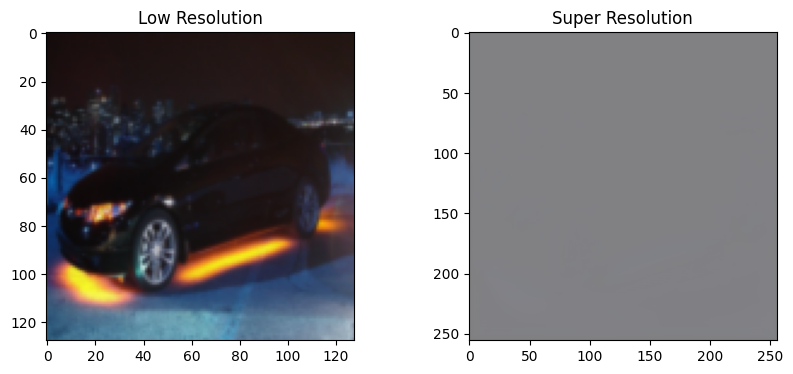

In [11]:
import matplotlib.pyplot as plt

test_img = x_val[0:1]
generated = generator.predict(test_img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Low Resolution")
plt.imshow(test_img[0])

plt.subplot(1,2,2)
plt.title("Super Resolution")
plt.imshow(generated[0])

plt.show()